In [4]:
import warnings
warnings.filterwarnings("ignore")


from nn.network import Network
from nn.layer import Layer
from nn.activation_functions import ReLU, Softmax, Sigmoid, Linear, Tanh
from nn.metrics import mse


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
from concurrent.futures import ThreadPoolExecutor, as_completed
import matplotlib.cm as cm

In [5]:
def visualize_convergence(train_path, test_path, models, lrs, epochs_list,
                          batch_size=32,
                          normalize=False,
                          mode="momentum",
                          momentum=0.9,
                          decay_rate=0.9,
                          random_seed_list=[42]):

    colors = cm.get_cmap('tab10', len(random_seed_list))

    # 1. Wczytanie danych z rzutowaniem na float32 dla dodatkowego przyspieszenia
    df_train = pd.read_csv(train_path)
    df_test = pd.read_csv(test_path)



    X_train_orig = df_train.iloc[:, 1:2].values.astype(np.float32)
    y_train_orig = df_train.iloc[:, -1:].values.astype(np.float32)

    X_test_orig = df_test.iloc[:, 1:2].values.astype(np.float32)
    y_test_orig = df_test.iloc[:, -1:].values.astype(np.float32)

    # 2. Opcjonalna normalizacja
    X_train, y_train = X_train_orig.copy(), y_train_orig.copy()
    X_test, y_test = X_test_orig.copy(), y_test_orig.copy()

    if normalize:
        x_min, x_max = X_train.min(axis=0), X_train.max(axis=0)
        y_min, y_max = y_train.min(axis=0), y_train.max(axis=0)

        x_ptp = np.where((x_max - x_min) == 0, 1, (x_max - x_min))
        y_ptp = np.where((y_max - y_min) == 0, 1, (y_max - y_min))

        X_train = (X_train - x_min) / x_ptp
        X_test = (X_test - x_min) / x_ptp

        y_train = (y_train - y_min) / y_ptp
        y_test = (y_test - y_min) / y_ptp

    epochs_sorted = sorted(epochs_list)
    x_plot_train = X_train_orig[:, 0]
    x_plot_test = X_test_orig[:, 0]

    # ==========================================
    # FUNKCJA POMOCNICZA DLA WĄTKU
    # ==========================================
    def run_single_seed(base_model, lr, seed):
        """Uruchamia pełny proces uczenia dla jednego startu wag i zwraca logi."""
        np.random.seed(seed)
        model = base_model()
        full_loss_history = []
        predictions_log = {}
        current_epoch = 0

        for ep in epochs_sorted:
            epochs_to_run = ep - current_epoch
            if epochs_to_run > 0:
                hist = model.fit_with_loss_history(X_train, y_train,
                                                   batch_size=batch_size,
                                                   epochs=epochs_to_run,
                                                   learning_rate=lr, mode=mode,
                                                   momentum=momentum, decay_rate=decay_rate)
                full_loss_history.extend(hist['loss'])

            pred_train_norm = model.predict(X_train)
            pred_test_norm = model.predict(X_test)

            if normalize:
                pred_train_unnorm = pred_train_norm * y_ptp + y_min
                pred_test_unnorm = pred_test_norm * y_ptp + y_min
            else:
                pred_train_unnorm = pred_train_norm
                pred_test_unnorm = pred_test_norm

            train_mse = mse(y_train_orig, pred_train_unnorm)
            test_mse = mse(y_test_orig, pred_test_unnorm)

            predictions_log[ep] = (pred_train_unnorm, pred_test_unnorm, train_mse, test_mse)
            current_epoch = ep

        return seed, full_loss_history, predictions_log

    # ==========================================
    # GŁÓWNA PĘTLA WYKONAWCZA I WIZUALIZACJA
    # ==========================================
    for model_idx, base_model in enumerate(models):
        for lr in lrs:
            print(f"\n{'='*80}")
            print(f"Trening Modelu {model_idx + 1} | Learning Rate: {lr}")
            print(f"{'='*80}")

            # Przygotowanie struktury pustych wykresów w głównym wątku
            fig_loss, ax_loss = plt.subplots(figsize=(10, 4))
            ax_loss.set_title(f"Model {model_idx + 1} | LR={lr} | Historia Błędu (Loss)")
            ax_loss.set_xlabel("Epoka")
            ax_loss.set_ylabel("Błąd (Trening)")
            ax_loss.grid(True, alpha=0.3)

            num_cols = len(epochs_sorted)
            fig_scatter, axes = plt.subplots(2, num_cols, figsize=(6 * num_cols, 12))

            if num_cols == 1:
                axes = np.array([[axes[0]], [axes[1]]])

            for i, ep in enumerate(epochs_sorted):
                axes[0, i].scatter(x_plot_train, y_train_orig, label='Prawdziwe', alpha=0.4, color='black', marker='x', s=20)
                axes[0, i].set_title(f"Trening | Epoka {ep} | LR {lr}", fontsize=11, fontweight='bold')
                axes[0, i].grid(True, alpha=0.3)

                axes[1, i].scatter(x_plot_test, y_test_orig, label='Prawdziwe', alpha=0.4, color='black', marker='x', s=20)
                axes[1, i].set_title(f"Test | Epoka {ep} | LR {lr}", fontsize=11, fontweight='bold')
                axes[1, i].grid(True, alpha=0.3)

            # --- OBLICZENIA RÓWNOLEGŁE ---
            results = []
            # Wykorzystujemy tyle wątków, ile mamy seedów do przetrenowania w danym modelu
            with ThreadPoolExecutor(max_workers=len(random_seed_list)) as executor:
                futures = {executor.submit(run_single_seed, base_model, lr, seed): seed for seed in random_seed_list}

                # Czekamy na zakończenie wątków i zbieramy wyniki
                for future in as_completed(futures):
                    results.append(future.result())

            # Sortujemy wyniki według kolejności zadanych seedów, żeby przypisywanie kolorów było deterministyczne
            results.sort(key=lambda x: random_seed_list.index(x[0]))

            # --- NIESIENIE WYNIKÓW NA WYKRESY (Główny wątek) ---
            for seed_idx, (seed, full_loss_history, predictions_log) in enumerate(results):
                color = colors(seed_idx)

                for i, ep in enumerate(epochs_sorted):
                    pred_train_unnorm, pred_test_unnorm, train_mse, test_mse = predictions_log[ep]
                    axes[0, i].scatter(x_plot_train, pred_train_unnorm,
                                       label=f'Seed {seed}, MSE: {train_mse:.4f}',
                                       alpha=0.6, color=color, s=15)
                    axes[1, i].scatter(x_plot_test, pred_test_unnorm,
                                       label=f'Seed {seed}, MSE: {test_mse:.4f}',
                                       alpha=0.6, color=color, s=15)

                ax_loss.plot(range(1, max(epochs_sorted) + 1), full_loss_history, color=color, linewidth=2, label=f'Seed {seed}')

            # Pokazanie legend i wykresów
            ax_loss.legend(loc='upper right')

            for i in range(num_cols):
                axes[0, i].legend(fontsize='small')
                axes[1, i].legend(fontsize='small')

            fig_scatter.tight_layout()
            plt.show()

ROZPOCZĘCIE TESTÓW DLA FUNKCJI SIGMOID

Trening Modelu 1 | Learning Rate: 0.001


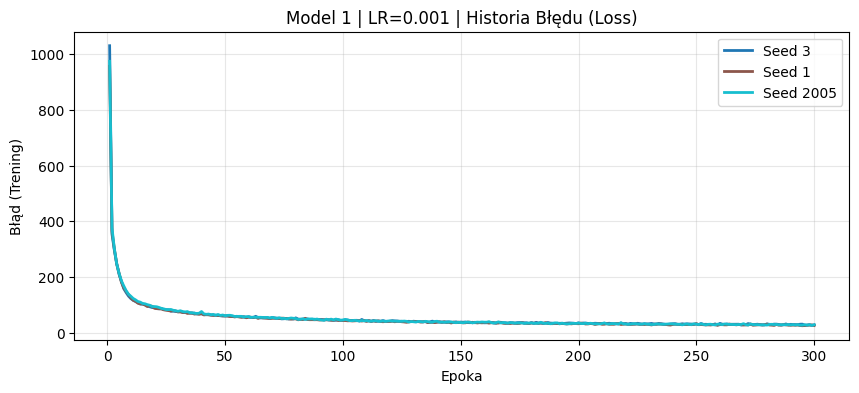

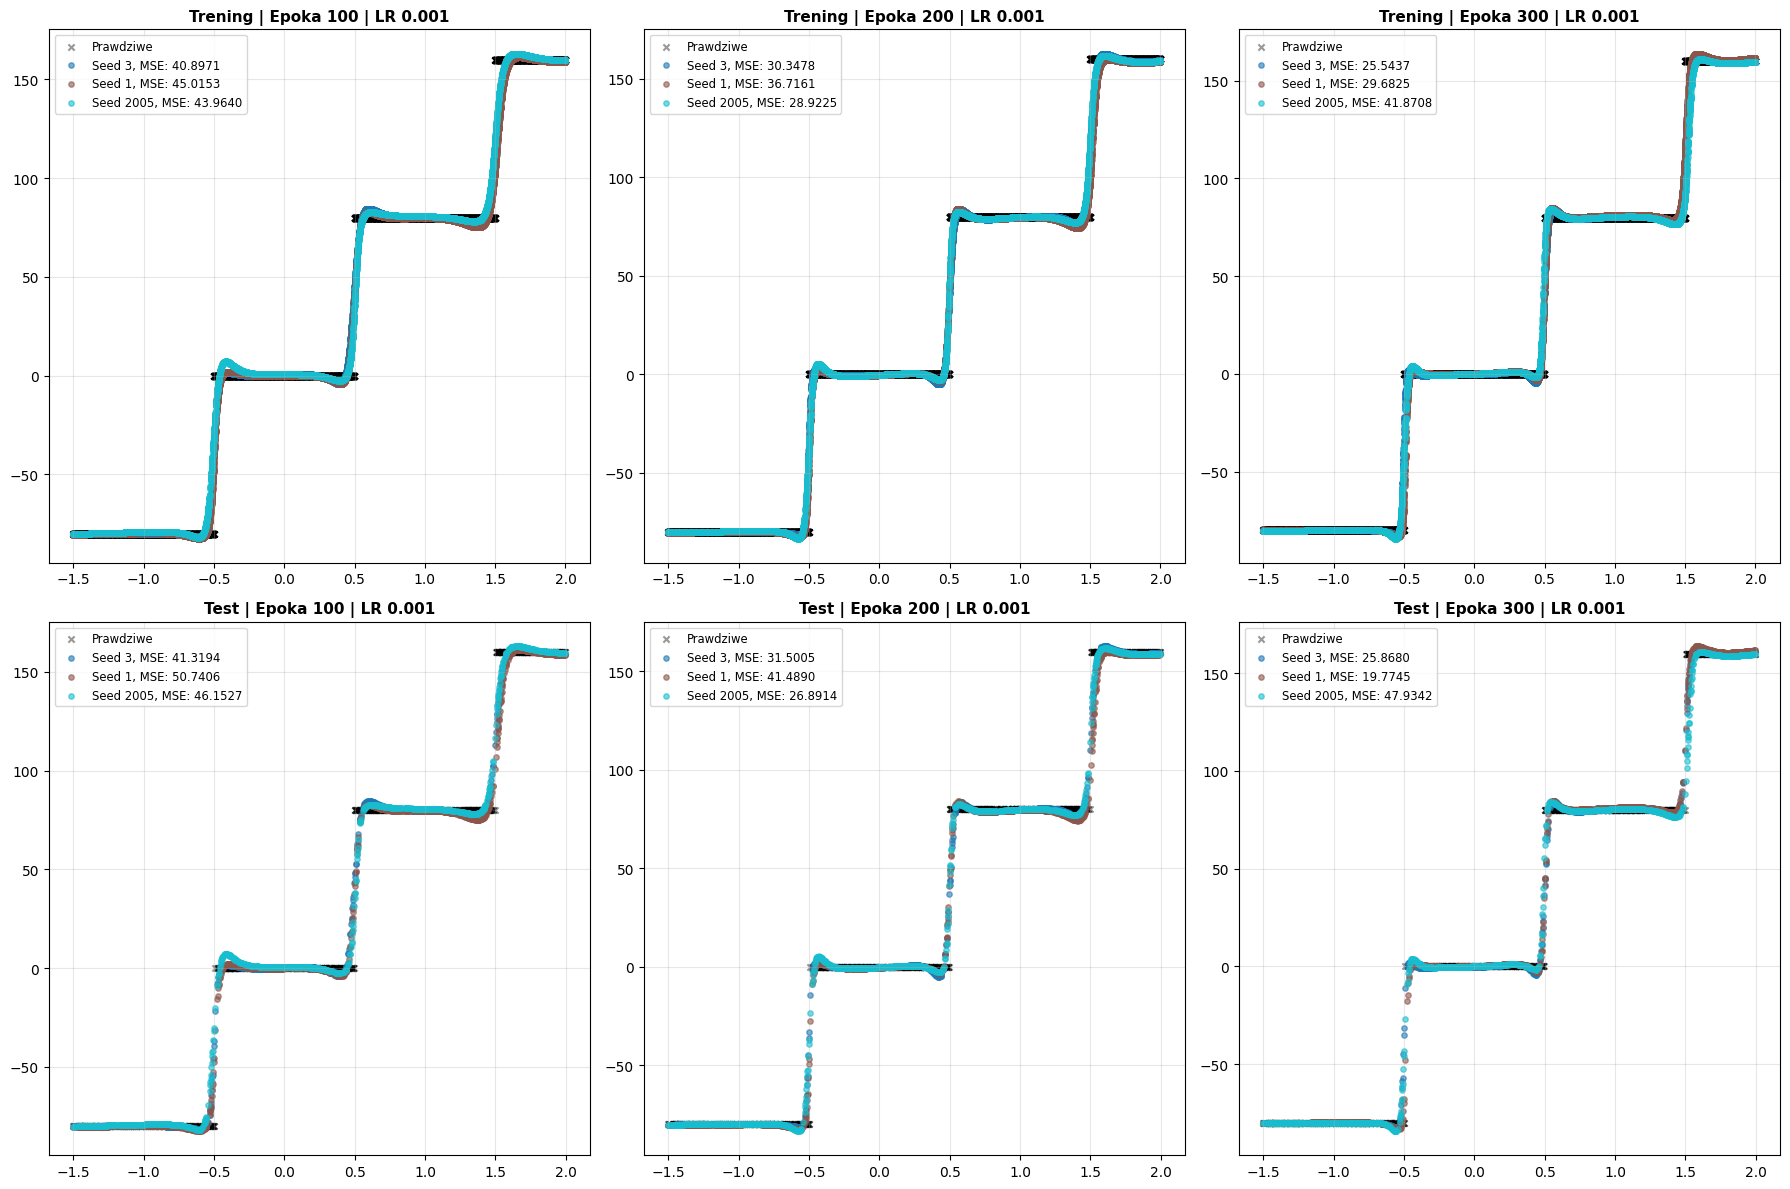


Trening Modelu 2 | Learning Rate: 0.001


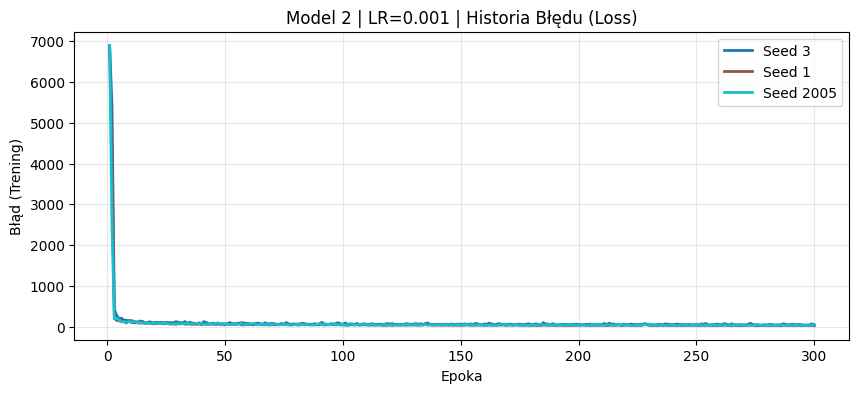

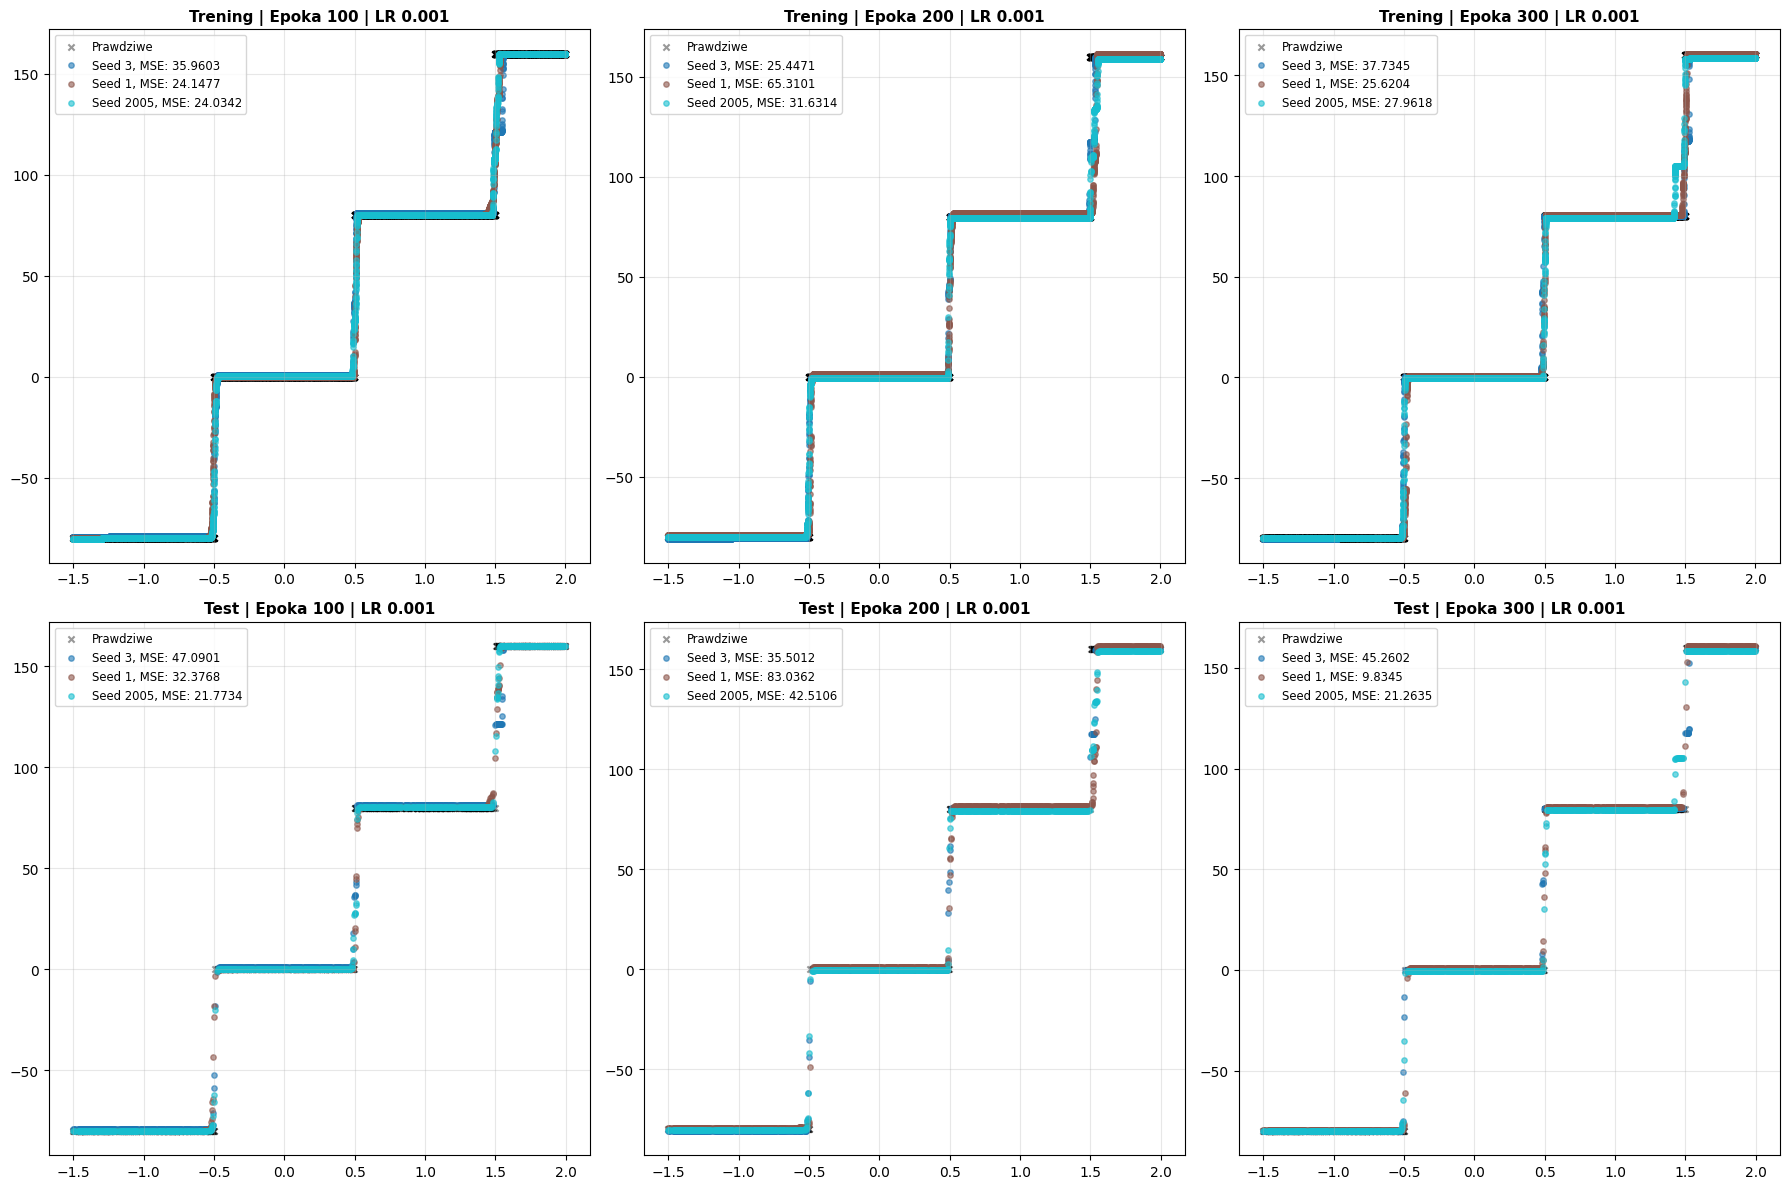

In [8]:
# ==========================================
# TEST 1: Funkcja aktywacji SIGMOID
# ==========================================

lista_modeli_sigmoid = [
    lambda: Network([Layer(1, 50, Sigmoid()),
                     Layer(50, 1, Linear())], task="regression"),

    lambda: Network([Layer(1, 50, Sigmoid()),
                     Layer(50, 25, Sigmoid()),
                     Layer(25, 1, Linear())], task="regression")

]

lista_lr = [0.001]
lista_epok = [100, 200, 300]

print("ROZPOCZĘCIE TESTÓW DLA FUNKCJI SIGMOID")
visualize_convergence('datasets/regression/steps-large-training.csv',
                      'datasets/regression/steps-large-test.csv',
                      lista_modeli_sigmoid,
                      lista_lr,
                      lista_epok,
                      normalize=False,
                      random_seed_list=[3, 1, 2005])

ROZPOCZĘCIE TESTÓW DLA FUNKCJI SIGMOID

Trening Modelu 1 | Learning Rate: 0.0001


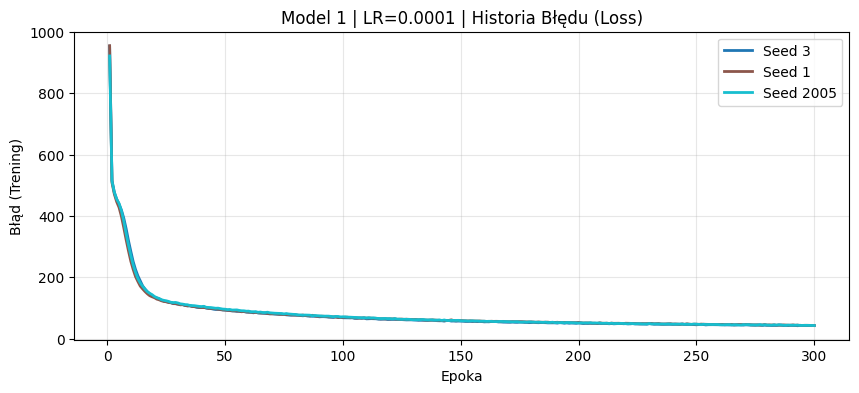

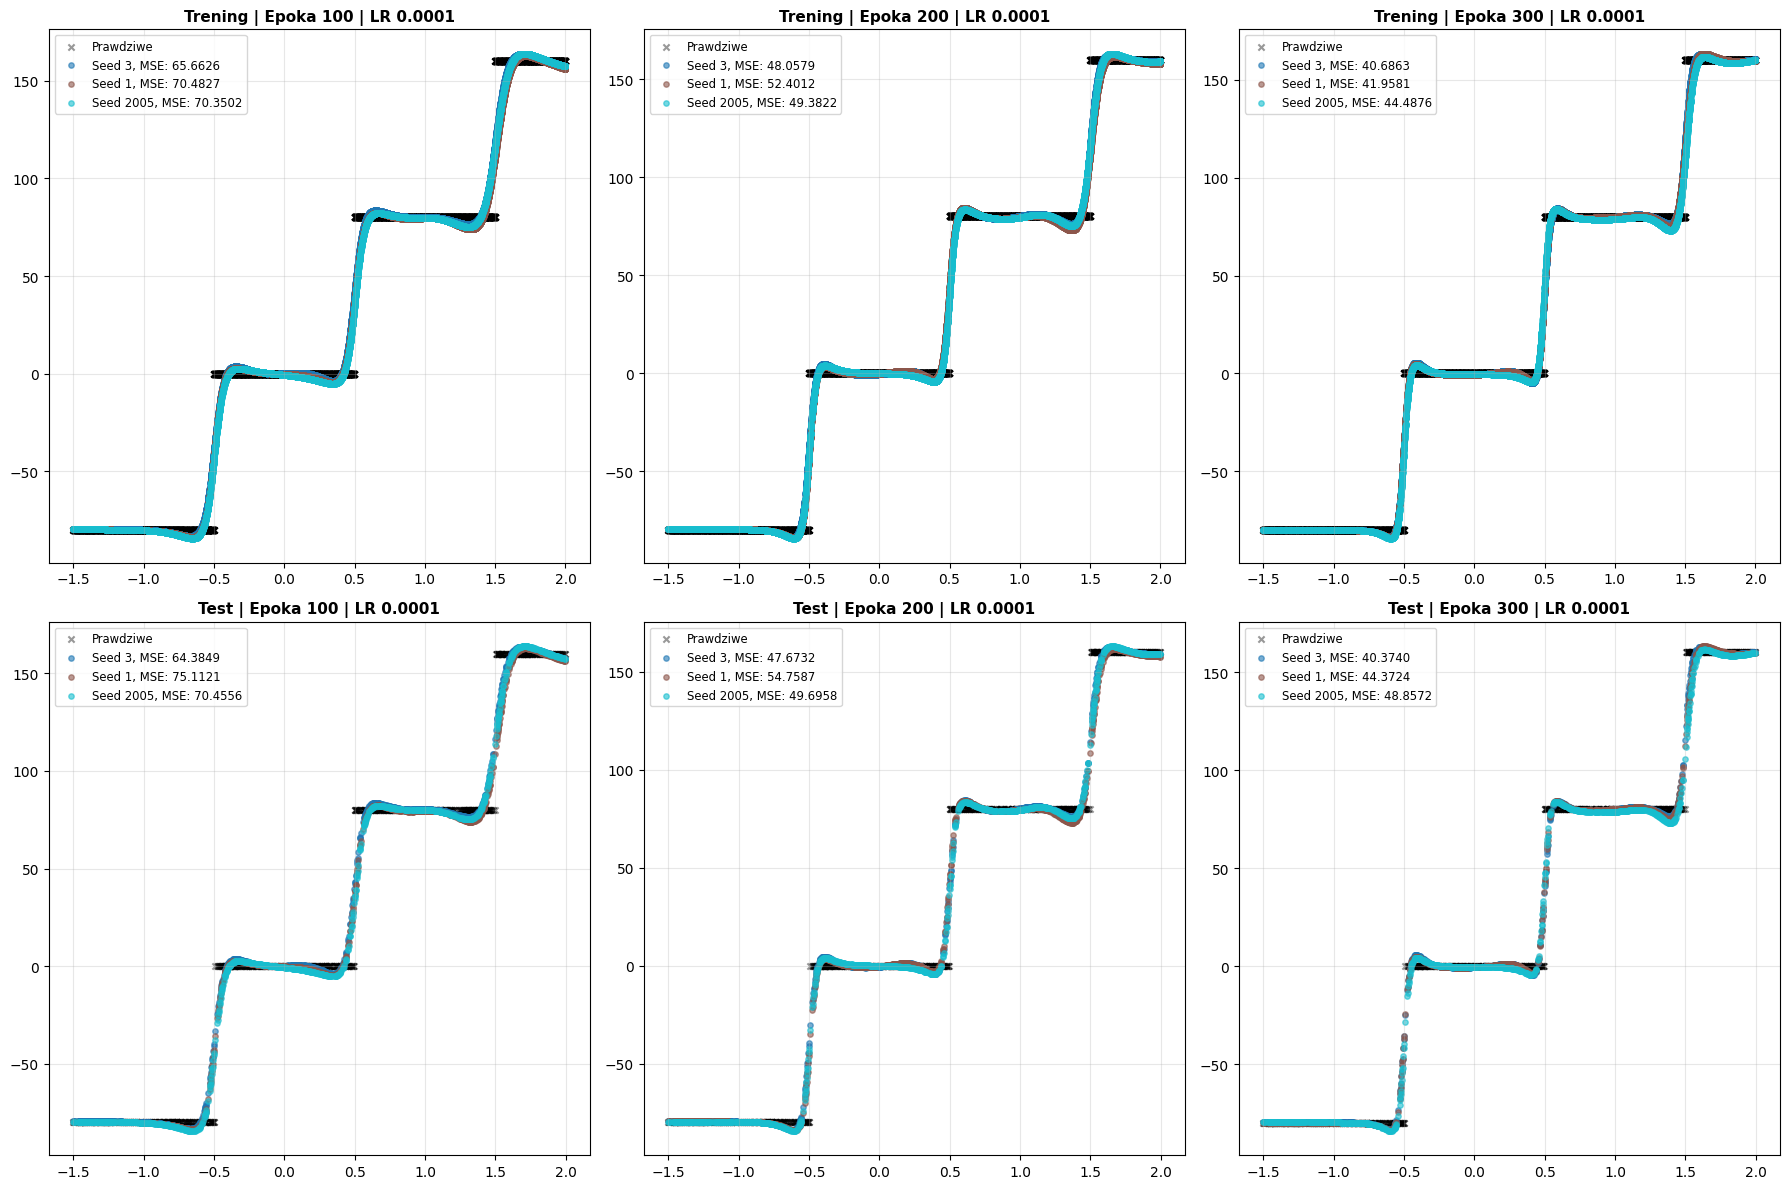


Trening Modelu 2 | Learning Rate: 0.0001


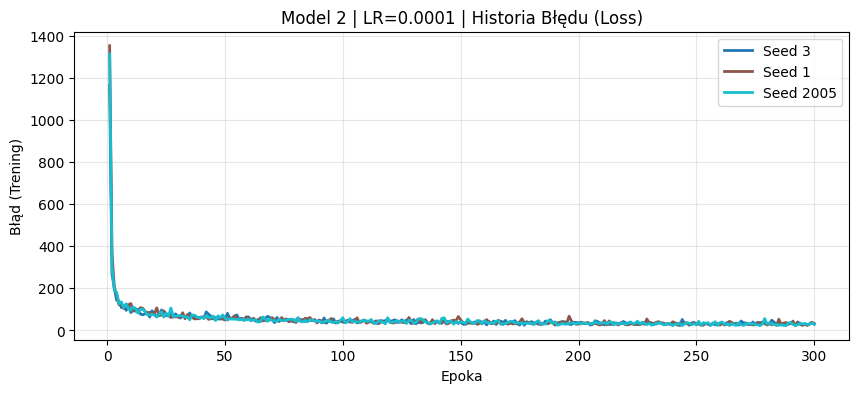

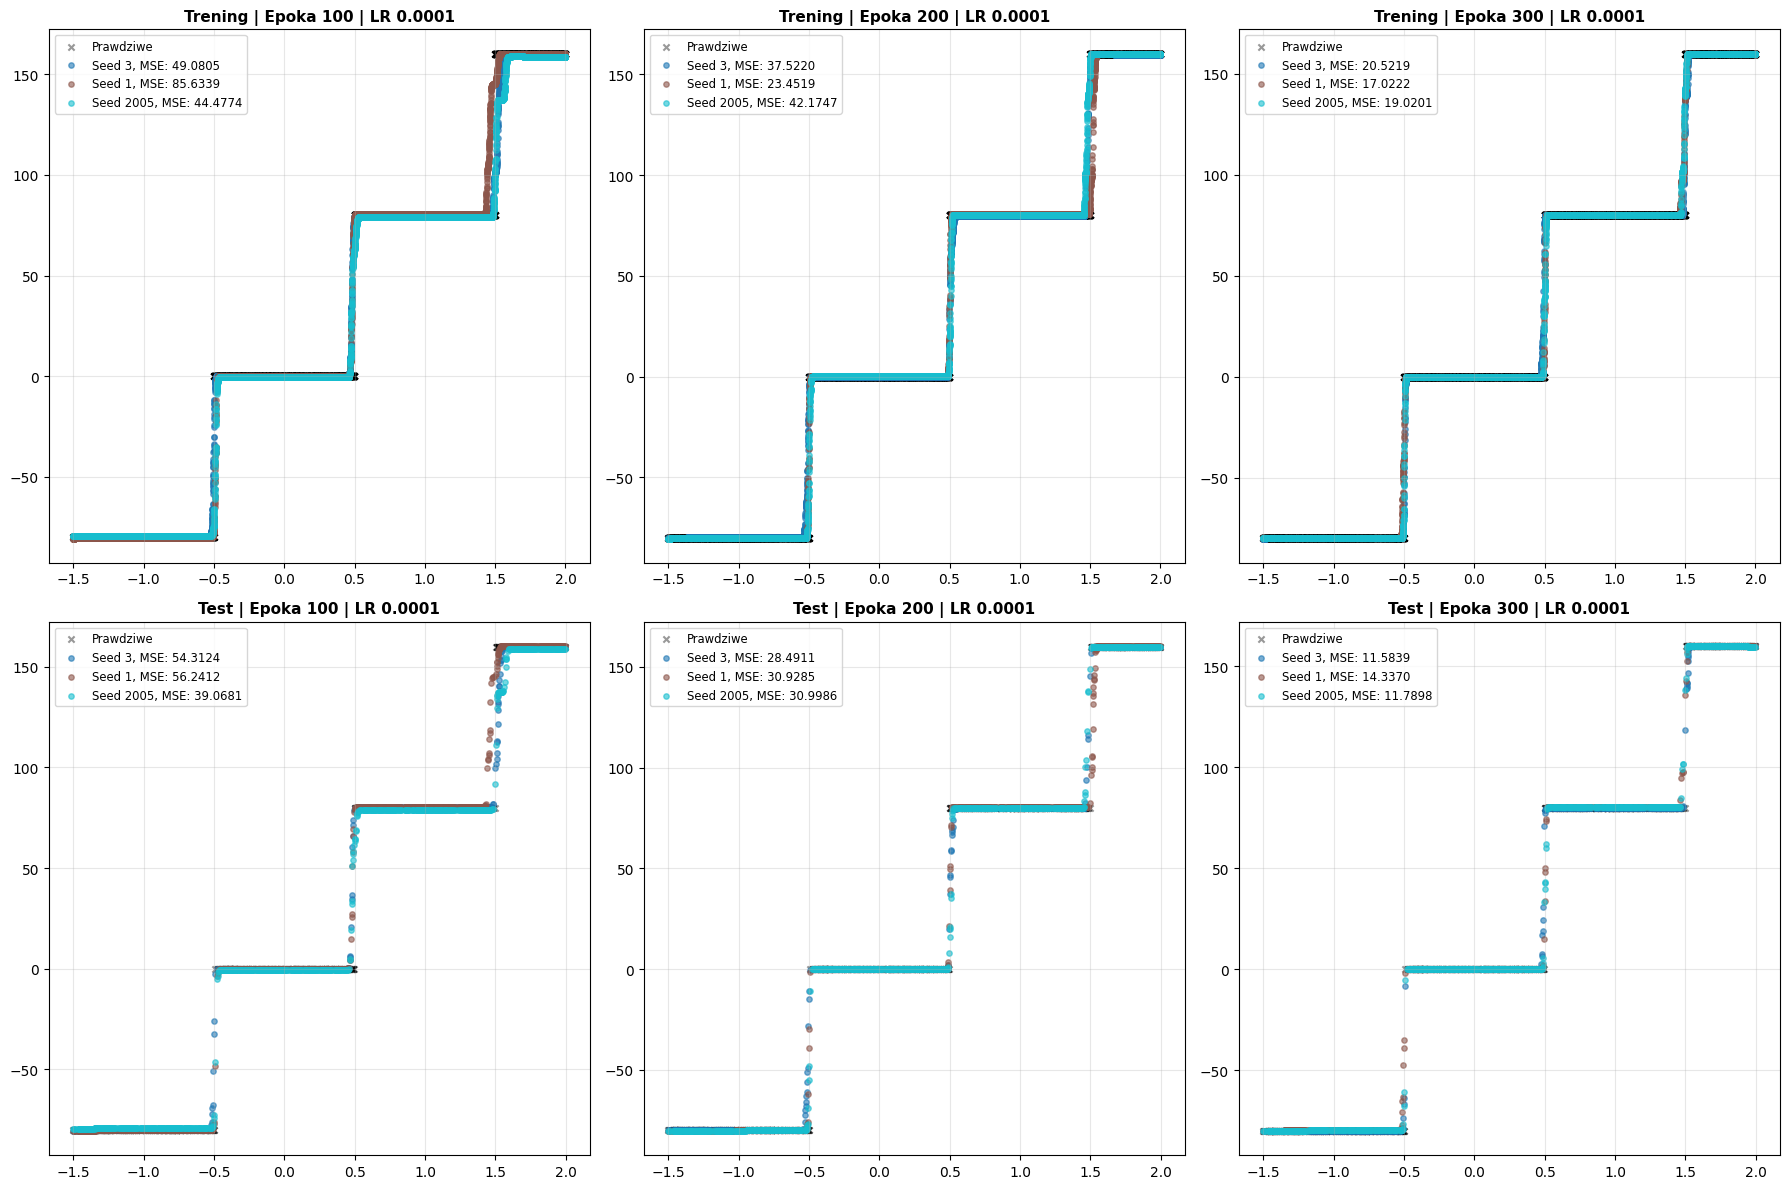

In [7]:
# ==========================================
# TEST 1: Funkcja aktywacji SIGMOID
# ==========================================

lista_modeli_sigmoid = [
    lambda: Network([Layer(1, 50, Tanh()),
                     Layer(50, 1, Linear())], task="regression"),

    lambda: Network([Layer(1, 50, Tanh()),
                     Layer(50, 25, Tanh()),
                     Layer(25, 1, Linear())], task="regression")

]

lista_lr = [0.0001]
lista_epok = [100, 200, 300]

print("ROZPOCZĘCIE TESTÓW DLA FUNKCJI Tanh")
visualize_convergence('datasets/regression/steps-large-training.csv',
                      'datasets/regression/steps-large-test.csv',
                      lista_modeli_sigmoid,
                      lista_lr,
                      lista_epok,
                      normalize=False,
                      random_seed_list=[3, 1, 2005])